1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

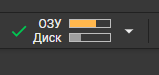



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [ ]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model
import tensorflow as tf

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:07<00:00, 27.6MB/s]


replace val/original/val_original_image_00000.bmp? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [ ]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.28c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [ ]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.27c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


## Решение


In [ ]:
# Определяем цветовую карту для 5 классов
CLASS_COLORS_5 = [
    (0, 0, 0),
    (100, 0, 0),
    (0, 100, 0),
    (0, 0, 100),
    (100, 100, 0)
]
NUM_CLASSES = 5

In [ ]:
def segments_to_array_5(img_list, class_colors, num_classes=5):
    num_samples = len(img_list)
    h, w = img_list[0].size[1], img_list[0].size[0]
    result = np.zeros((num_samples, h, w, num_classes), dtype='float32')
    for i, img in enumerate(img_list):
        img_arr = np.array(img)
        for class_idx, color in enumerate(class_colors):
            mask = np.all(img_arr == color, axis=-1)
            result[i, :, :, class_idx] = mask.astype('float32')
    bg_mask = 1.0 - np.sum(result, axis=-1)
    result[:, :, :, 0] = np.maximum(result[:, :, :, 0], bg_mask)
    return result

In [ ]:
# X храним как uint8
x_train = np.array([image.img_to_array(img) for img in train_images], dtype='uint8')
x_val = np.array([image.img_to_array(img) for img in val_images], dtype='uint8')

# Y храним как int8
def segments_to_class_map(seg_list, class_colors, num_classes=5):
    h, w = seg_list[0].size[1], seg_list[0].size[0]
    result = np.zeros((len(seg_list), h, w), dtype='int8')

    for i, seg in enumerate(seg_list):
        seg_arr = np.array(seg)
        for class_idx, color in enumerate(class_colors):
            mask = np.all(seg_arr == color, axis=-1)
            result[i, mask] = class_idx
    return result

y_train = segments_to_class_map(train_segments, CLASS_COLORS_5, NUM_CLASSES)
y_val = segments_to_class_map(val_segments, CLASS_COLORS_5, NUM_CLASSES)

print(f"x_train: {x_train.shape} dtype={x_train.dtype} ~{x_train.nbytes/1024/1024:.1f} MB")
print(f"y_train: {y_train.shape} dtype={y_train.dtype} ~{y_train.nbytes/1024/1024:.1f} MB")

x_train: (1900, 192, 256, 3) dtype=uint8 ~267.2 MB
y_train: (1900, 192, 256) dtype=int8 ~89.1 MB


In [ ]:
from tensorflow.keras.layers import Rescaling

def build_unet_custom(input_shape, num_classes, filters_base=24, kernel_size=3, activation='relu'):
    inputs = Input(input_shape)

    x = Rescaling(1.0/255.0)(inputs)

    # Энкодер
    c1 = Conv2D(filters_base, kernel_size, padding='same')(x)
    c1 = BatchNormalization()(c1)
    c1 = Activation(activation)(c1)
    c1 = Conv2D(filters_base, kernel_size, padding='same')(c1)
    c1 = BatchNormalization()(c1)
    c1 = Activation(activation)(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(filters_base*2, kernel_size, padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Activation(activation)(c2)
    c2 = Conv2D(filters_base*2, kernel_size, padding='same')(c2)
    c2 = BatchNormalization()(c2)
    c2 = Activation(activation)(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(filters_base*4, kernel_size, padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Activation(activation)(c3)
    c3 = Conv2D(filters_base*4, kernel_size, padding='same')(c3)
    c3 = BatchNormalization()(c3)
    c3 = Activation(activation)(c3)
    p3 = MaxPooling2D(2)(c3)

    c4 = Conv2D(filters_base*8, kernel_size, padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Activation(activation)(c4)
    c4 = Conv2D(filters_base*8, kernel_size, padding='same')(c4)
    c4 = BatchNormalization()(c4)
    c4 = Activation(activation)(c4)
    p4 = MaxPooling2D(2)(c4)

    # Bottleneck
    c5 = Conv2D(filters_base*16, kernel_size, padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Activation(activation)(c5)
    c5 = Conv2D(filters_base*16, kernel_size, padding='same')(c5)
    c5 = BatchNormalization()(c5)
    c5 = Activation(activation)(c5)

    # Декодер
    u6 = Conv2DTranspose(filters_base*8, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(filters_base*8, kernel_size, padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Activation(activation)(c6)
    c6 = Conv2D(filters_base*8, kernel_size, padding='same')(c6)
    c6 = BatchNormalization()(c6)
    c6 = Activation(activation)(c6)

    u7 = Conv2DTranspose(filters_base*4, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(filters_base*4, kernel_size, padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Activation(activation)(c7)
    c7 = Conv2D(filters_base*4, kernel_size, padding='same')(c7)
    c7 = BatchNormalization()(c7)
    c7 = Activation(activation)(c7)

    u8 = Conv2DTranspose(filters_base*2, 2, strides=2, padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(filters_base*2, kernel_size, padding='same')(u8)
    c8 = BatchNormalization()(c8)
    c8 = Activation(activation)(c8)
    c8 = Conv2D(filters_base*2, kernel_size, padding='same')(c8)
    c8 = BatchNormalization()(c8)
    c8 = Activation(activation)(c8)

    u9 = Conv2DTranspose(filters_base, 2, strides=2, padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(filters_base, kernel_size, padding='same')(u9)
    c9 = BatchNormalization()(c9)
    c9 = Activation(activation)(c9)
    c9 = Conv2D(filters_base, kernel_size, padding='same')(c9)
    c9 = BatchNormalization()(c9)
    c9 = Activation(activation)(c9)

    outputs = Conv2D(num_classes, 1, activation='softmax')(c9)
    return Model(inputs=[inputs], outputs=[outputs])

In [ ]:
def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.int32)
    intersection = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.float32))
    union = tf.reduce_sum(tf.cast(tf.not_equal(y_true, y_pred), tf.float32)) + intersection
    return intersection / (union + 1e-7)

In [ ]:
def train_and_evaluate(name, filters_base, kernel_size, activation, epochs=7):
    print(f"\n Эксперимент: {name} (f={filters_base}, k={kernel_size}, act={activation})")

    model = build_unet_custom((IMG_WIDTH, IMG_HEIGHT, 3), NUM_CLASSES, filters_base, kernel_size, activation)
    model.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy', iou_coef])

    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(256).batch(16).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=val_dataset,
        verbose=1
    )

    result = {
        'name': name,
        'filters': filters_base,
        'kernel': kernel_size,
        'activation': activation,
        'history': history.history,
        'model': model
    }
    return result

In [ ]:
def plot_results(results, epochs=7):
    plt.figure(figsize=(14, 8))
    plt.subplot(2, 2, 1)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_accuracy'], label=r['name'], marker='o')
    plt.title('val_accuracy'), plt.xlabel('Эпоха'), plt.legend(), plt.grid(True)

    plt.subplot(2, 2, 2)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_iou_coef'], label=r['name'], marker='s')
    plt.title('val_iou'), plt.xlabel('Эпоха'), plt.legend(), plt.grid(True)

    plt.subplot(2, 2, 3)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['loss'], label=r['name'], marker='^')
    plt.title('train_loss'), plt.xlabel('Эпоха'), plt.legend(), plt.grid(True)

    plt.subplot(2, 2, 4)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_loss'], label=r['name'], marker='d')
    plt.title('val_loss'), plt.xlabel('Эпоха'), plt.legend(), plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def mask_to_rgb(mask, colors):
    idx = np.argmax(mask, axis=-1)
    rgb = np.zeros((idx.shape[0], idx.shape[1], 3), dtype='uint8')
    for i, c in enumerate(colors):
        rgb[idx == i] = c
    return rgb

In [ ]:
def show_predictions(results, x_val, y_val, colors, n=2):
    for r in results[:3]:
        print(f"\n--- {r['name']} ---")
        preds = r['model'].predict(x_val[:n])
        for i in range(n):
            plt.figure(figsize=(16, 4))
            plt.subplot(1, 4, 1); plt.imshow(x_val[i]); plt.title('Оригинал'); plt.axis('off')
            plt.subplot(1, 4, 2); plt.imshow(mask_to_rgb(y_val[i], colors)); plt.title('Истина'); plt.axis('off')
            plt.subplot(1, 4, 3); plt.imshow(mask_to_rgb(preds[i], colors)); plt.title('Предсказание'); plt.axis('off')
            diff = (np.argmax(y_val[i], axis=-1) != np.argmax(preds[i], axis=-1)).astype(np.uint8) * 255
            plt.subplot(1, 4, 4); plt.imshow(diff, cmap='gray'); plt.title('Ошибки'); plt.axis('off')
            plt.show()

In [ ]:
experiments = [
    # Изменение фильтров (3 эксперимента)
    ("Filters_16", 16, 3, "relu"),
    ("Base_24x3_relu", 24, 3, "relu"),
    ("Filters_32", 32, 3, "relu"),

    # Изменение kernel_size (2 эксперимента)
    ("Kernel_5", 24, 5, "relu"),
    ("Kernel_7", 24, 7, "relu"),

    # Изменение активации (3 эксперимента)
    ("Act_linear", 24, 3, "linear"),
    ("Act_selu", 24, 3, "selu"),
    ("Act_elu", 24, 3, "elu"),

    # Комбинированные (2 эксперимента)
    ("Comb_F16_K5_elu", 16, 5, "elu"),
    ("Comb_F32_K7_selu", 32, 7, "selu"),
]
EPOCHS = 7

In [ ]:
all_results = []

for name, f, k, act in experiments:
    gc.collect()
    tf.keras.backend.clear_session()

    result = train_and_evaluate(name, f, k, act, EPOCHS)
    all_results.append(result)

    gc.collect()
    tf.keras.backend.clear_session()

    print(f"\n Эксперимент '{name}' завершен\n")
    print("="*60)


 Эксперимент: Filters_16 (f=16, k=3, act=relu)
Epoch 1/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 230ms/step - accuracy: 0.2158 - iou_coef: 0.2160 - loss: 1.6781 - val_accuracy: 0.3406 - val_iou_coef: 0.3377 - val_loss: 1.5496
Epoch 2/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.5089 - iou_coef: 0.5089 - loss: 1.3854 - val_accuracy: 0.5238 - val_iou_coef: 0.5228 - val_loss: 1.4323
Epoch 3/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.6532 - iou_coef: 0.6532 - loss: 1.1898 - val_accuracy: 0.6303 - val_iou_coef: 0.6239 - val_loss: 1.2342
Epoch 4/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.7234 - iou_coef: 0.7234 - loss: 1.0383 - val_accuracy: 0.6500 - val_iou_coef: 0.6356 - val_loss: 1.1470
Epoch 5/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.7601 - iou_coef: 0.7599 - loss: 0.9384 - val_accuracy: 0.6757 - val_iou_coef: 0.6649 - val_loss: 1.0928
Epoch 6/7
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - accuracy: 0.7748 - iou_coef: 0.7747 

In [ ]:
print("\n" + "="*80)
print(f"{'Эксперимент':<22} {'Val Acc':<12} {'Val IoU':<12}")
print("="*80)
for r in all_results:
    val_acc = r['history']['val_accuracy'][-1]
    val_iou = r['history']['val_iou_coef'][-1]
    print(f"{r['name']:<22} {val_acc:<12.4f} {val_iou:<12.4f}")
print("="*80)

best = max(all_results, key=lambda x: x['history']['val_iou_coef'][-1])
print(f"\n Лучшая: {best['name']} (Val IoU = {best['history']['val_iou_coef'][-1]:.4f})")


Эксперимент            Val Acc      Val IoU     
Filters_16             0.6886       0.6822      
Base_24x3_relu         0.7121       0.7099      
Filters_32             0.7257       0.7233      
Kernel_5               0.7276       0.7228      
Kernel_7               0.7083       0.7044      
Act_linear             0.6656       0.6576      
Act_selu               0.7055       0.7001      
Act_elu                0.6827       0.6775      
Comb_F16_K5_elu        0.7091       0.7008      
Comb_F32_K7_selu       0.7072       0.7003      

 Лучшая: Filters_32 (Val IoU = 0.7233)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


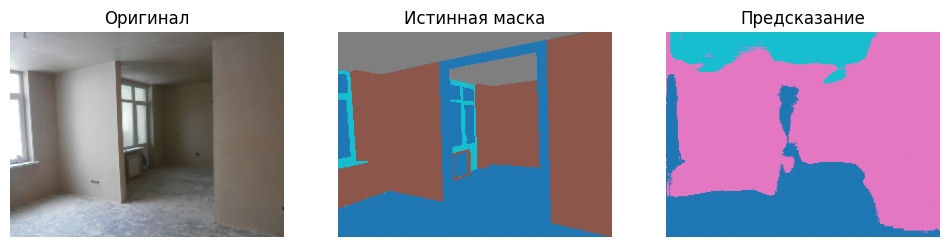

In [ ]:
# Визуализация лучшей модели на примере
best_model = best['model']
idx = 0

pred = best_model.predict(x_val[idx:idx+1])
pred_mask = np.argmax(pred, axis=-1)[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_val[idx])
axes[0].set_title('Оригинал')
axes[1].imshow(y_val[idx], cmap='tab10')
axes[1].set_title('Истинная маска')
axes[2].imshow(pred_mask, cmap='tab10')
axes[2].set_title('Предсказание')
for ax in axes:
    ax.axis('off')
plt.show()

#### Лучший результат достигнут на конфигурации filters=32, kernel=3, activation=relu с Val IoU = 0.7233. Увеличение количества фильтров положительно влияет на качество. Линейная активация показывает худшие результаты. Увеличение ядра свертки свыше 5 ухудшает качество при значительном росте времени обучения.